<a href="https://colab.research.google.com/github/sarrinah123/ML/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMP3010 Machine Learning Assignment 2026
Name:           Sarrinah Lauthan

Student ID:     22427746

## Objective
Predict the peak pressure generated by the BLEVE explosion using machine learning.

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pandas is used to handle the data

numpy is used for the mathematical operations

matplotlib is used for the graph plots

seaborn is used for a better visualisation

Upload and load Data

In [2]:
from google.colab import files
files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


{'test.csv': b'ID,Tank Failure Pressure (bar),Liquid Ratio (%),Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),Obstacle Distance to BLEVE (m),Obstacle Width (m),Obstacle Height (m),Obstacle Thickness (m),Obstacle Angle,Status,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z\r\n0,16.8,0.3364263,2.8,8.6,2.2,0.4,1.6,389.9,387.2,10,12,5,0.6,1,Superheated,37.9,-1,152,1,1,12.05,-5.6,-1\r\n1,16.8,0.3364263,2.8,8.6,2.2,0.4,1.6,389.9,387.2,10,12,5,0.6,1,Superheated,37.9,-1,152,2,1,12.05,-5.6,1.3\r\n2,16.8,0.3364263,2.8,8.6,2.2,0.4,1.6,389.9,387.2,10,12,5,0.6,1,Superheated,37.9,-1,152,3,1,12.05,-5.6,3.6\r\n3,16.8,0.3364263,2.8,8.6,2.2,0.4,1.6,389.9,387.2,10,12,5,0.6,1,Superheated,37.9,-1,152,4,1,12.05,0.2,-1\r\n4,16.8,0.3364263,2.8,8.6,2.2,0.4,1.6,389.9,387.2,10,12,5,0.6,1,Superheated,37.9

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train.head()

,ID,Tank Failure Pressure (bar),Liquid Ratio (%),Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Status,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar)
0,3203.0,7.32,0.42,2.42,5.39,1.00,1.79,0.60,524.61,354.49,...,Superheated,37.9,-1.0,152.0,18.0,2.0,12.15,7.90,10.7,0.199929
1,3204.0,7.18,0.42,2.39,5.39,1.01,1.81,0.59,522.80,354.31,...,Superheated,37.9,-1.0,152.0,19.0,3.0,12.50,-2.95,-1.9,0.435681
2,3205.0,7.32,0.41,2.39,5.38,1.00,1.78,0.62,523.00,354.59,...,Superheated,37.9,-1.0,152.0,20.0,3.0,12.50,-2.95,4.4,0.264031
3,3206.0,7.26,0.42,2.40,5.41,1.00,1.81,0.61,522.35,354.37,...,Superheated,37.9,-1.0,152.0,21.0,3.0,12.50,-2.95,10.7,0.270576
4,3207.0,7.32,0.42,2.40,5.41,1.02,1.79,0.62,522.98,354.33,...,Superheated,37.9,-1.0,152.0,22.0,4.0,12.50,-2.70,11.0,0.204675


## Data Exploration

The dataset is explore in oder to get a better understanding of its structure, reatures and potential issues.

Shows the size of the dataset

In [4]:
train.shape

(10050, 25)

Shows the data types and the missing values

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               10045 non-null  float64
 1   Tank Failure Pressure (bar)      10043 non-null  float64
 2   Liquid Ratio (%)                 10041 non-null  float64
 3   Tank Width (m)                   10041 non-null  float64
 4   Tank Length (m)                  10041 non-null  float64
 5   Tank Height (m)                  10042 non-null  float64
 6   BLEVE Height (m)                 10040 non-null  float64
 7   Vapour Height (m)                10041 non-null  float64
 8   Vapour Temperature (K)           10022 non-null  float64
 9   Liquid Temperature (K)           10023 non-null  float64
 10  Obstacle Distance to BLEVE (m)   10042 non-null  float64
 11  Obstacle Width (m)               10044 non-null  float64
 12  Obstacle Height (m

Shows the distribution (the mean, min max, etc)

In [6]:
train.describe()

,ID,Tank Failure Pressure (bar),Liquid Ratio (%),Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),...,Obstacle Angle,Liquid Critical Pressure (bar),Liquid Boiling Temperature (K),Liquid Critical Temperature (K),Sensor ID,Sensor Position Side,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar)
count,10045.000000,10043.000000,10041.000000,10041.000000,10041.000000,10042.000000,10040.000000,10041.000000,10022.000000,10023.000000,...,10042.000000,10020.000000,10021.000000,10020.000000,10042.000000,10042.000000,10043.000000,10042.000000,10041.000000,10040.000000
mean,8202.729119,37.899252,0.504288,1.696627,5.599281,1.673800,1.023503,0.845691,396.755388,343.460330,...,14.598686,40.099461,-20.593753,125.542096,14.010655,2.335491,12.906879,2.984879,3.077263,0.360492
std,2885.998522,225.634505,0.228073,0.764937,2.596056,0.751931,0.575464,0.536538,71.876848,35.536412,...,9.237134,2.297916,20.480981,27.625669,7.791718,1.334306,4.158897,4.712319,4.213429,0.495271
min,3203.000000,4.920000,0.100000,0.380000,0.580000,0.380000,-0.020000,0.180000,281.210000,282.950000,...,0.000000,37.900000,-42.000000,96.700000,1.000000,1.000000,5.150000,-9.050000,-2.800000,0.016098
25%,5705.000000,13.730000,0.300000,1.010000,3.380000,1.010000,0.590000,0.400000,336.620000,312.810000,...,6.000000,37.900000,-42.000000,96.700000,7.000000,1.000000,9.300000,-0.200000,-0.600000,0.102211
50%,8206.000000,22.940000,0.510000,1.620000,5.620000,1.610000,1.010000,0.780000,386.725000,342.330000,...,15.000000,37.900000,-1.000000,152.000000,14.000000,2.000000,12.700000,2.800000,2.300000,0.206346
75%,10701.000000,32.190000,0.700000,2.390000,7.810000,2.390000,1.580000,1.200000,441.965000,365.320000,...,22.000000,42.500000,-1.000000,152.000000,21.000000,3.000000,16.250000,6.400000,5.300000,0.413180
max,13202.000000,4995.616406,0.900000,3.020000,10.020000,3.020000,2.020000,2.620000,573.300000,424.600000,...,30.000000,42.500000,-1.000000,152.000000,27.000000,5.000000,23.750000,19.550000,16.700000,9.170477


Identifies the missing values

In [7]:
train.isnull().sum()

,0
ID,5
Tank Failure Pressure (bar),7
Liquid Ratio (%),9
Tank Width (m),9
Tank Length (m),9
Tank Height (m),8
BLEVE Height (m),10
Vapour Height (m),9
Vapour Temperature (K),28
Liquid Temperature (K),27


Analysing the output variables to better understand the prediction

In [8]:
train["Target Pressure (bar)"].describe()

,Target Pressure (bar)
count,10040.000000
mean,0.360492
std,0.495271
min,0.016098
25%,0.102211
50%,0.206346
75%,0.413180
max,9.170477


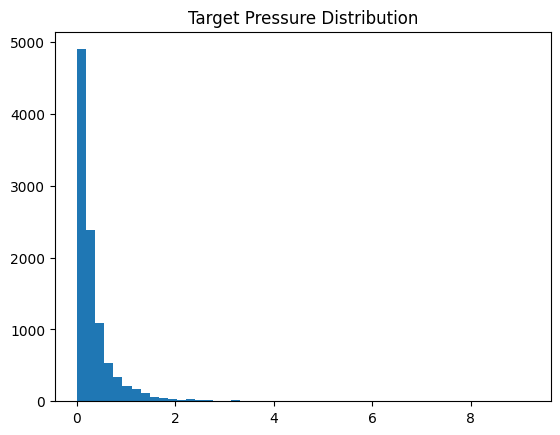

In [9]:
plt.hist(train["Target Pressure (bar)"], bins=50)
plt.title("Target Pressure Distribution")
plt.show()

## Data Cleaning
The missing values and the irrelevant features are handled to further prepare the dataset.

Removing missing target

In [10]:
train = train.dropna(subset=["Target Pressure (bar)"])

Removing IDs

In [11]:
train = train.drop(columns=["ID"])
test = test.drop(columns=["ID"])

Fill the missing values

In [12]:
train = train.fillna(train.median(numeric_only=True))
test = test.fillna(test.median(numeric_only=True))

Fixing categories

In [13]:
train["Status"] = train["Status"].fillna("unknown")
test["Status"] = test["Status"].fillna("unknown")

Checking for dduplicates

In [14]:
train.duplicated().sum()

np.int64(50)

Outlier detection

<Axes: xlabel='Target Pressure (bar)'>

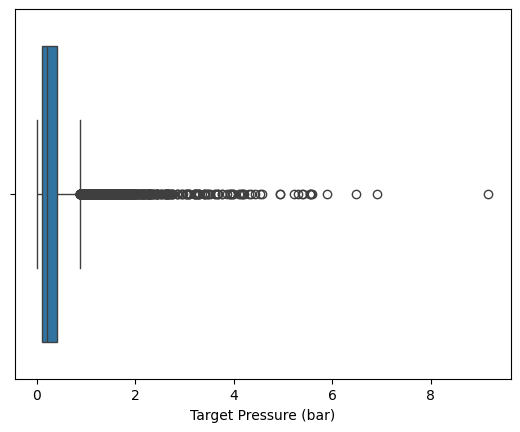

In [15]:
sns.boxplot(x=train["Target Pressure (bar)"])

Removing extreme outliers

In [16]:
Q1 = train["Target Pressure (bar)"].quantile(0.25)
Q3 = train["Target Pressure (bar)"].quantile(0.75)
IQR = Q3 -Q1

train = train[
    (train["Target Pressure (bar)"] >= Q1 - 1.5 * IQR) &
    (train["Target Pressure (bar)"] <= Q3 + 1.5 * IQR)
]
train = train.copy()

## Feature Enginnering
New features are created in order to improve the model's performance

Tank Ratio

In [17]:
train["tank_ratio"] = train["Tank Width (m)"] / train["Tank Length (m)"]
test["tank_ratio"] = test["Tank Width (m)"] / test["Tank Length (m)"]

Tank Volume

In [18]:
train["tank_volume"] = (
    train["Tank Width (m)"] *
    train["Tank Height (m)"] *
    train["Tank Length (m)"]
)

test["tank_volume"] = (
    test["Tank Width (m)"] *
    test["Tank Height (m)"] *
    test["Tank Length (m)"]
)

Temparature Difference

In [19]:
train["temp_diff"] = train["Vapour Temperature (K)"] - train["Liquid Temperature (K)"]
test["temp_diff"] = test["Vapour Temperature (K)"] - test["Liquid Temperature (K)"]

Bonus features 1 - Sensor Distance

In [20]:
train["sensor_distance"] = np.sqrt(
    train["Sensor Position x"]**2 +
    train["Sensor Position y"]**2 +
    train["Sensor Position z"]**2
)

test["sensor_distance"] = np.sqrt (
    test["Sensor Position x"]**2 +
    test["Sensor Position y"]**2 +
    test["Sensor Position z"]**2
)

Bonus features 2 - Obstacle Area

In [21]:
train["obstacle_area"] = (
    train["Obstacle Width (m)"] *
    train["Obstacle Height (m)"]
)

test["obstacle_area"] = (
    test["Obstacle Width (m)"] *
    test["Obstacle Height (m)"]
)

Bonus feature 3 - Pressure-Temparature Ratio

In [22]:
train["pressure_temp_ratio"] = (
    train["Tank Failure Pressure (bar)"] /
    train["Vapour Temperature (K)"]
)

test["pressure_temp_ratio"] = (
    test["Tank Failure Pressure (bar)"] /
    test["Vapour Temperature (K)"]
)

In [23]:
train.head()

,Tank Failure Pressure (bar),Liquid Ratio (%),Tank Width (m),Tank Length (m),Tank Height (m),BLEVE Height (m),Vapour Height (m),Vapour Temperature (K),Liquid Temperature (K),Obstacle Distance to BLEVE (m),...,Sensor Position x,Sensor Position y,Sensor Position z,Target Pressure (bar),tank_ratio,tank_volume,temp_diff,sensor_distance,obstacle_area,pressure_temp_ratio
0,7.32,0.42,2.42,5.39,1.00,1.79,0.60,524.61,354.49,11.0,...,12.15,7.90,10.7,0.199929,0.448980,13.043800,170.12,18.014508,143.0,0.013953
1,7.18,0.42,2.39,5.39,1.01,1.81,0.59,522.80,354.31,11.0,...,12.50,-2.95,-1.9,0.435681,0.443414,13.010921,168.49,12.983162,143.0,0.013734
2,7.32,0.41,2.39,5.38,1.00,1.78,0.62,523.00,354.59,11.0,...,12.50,-2.95,4.4,0.264031,0.444238,12.858200,168.41,13.576174,143.0,0.013996
3,7.26,0.42,2.40,5.41,1.00,1.81,0.61,522.35,354.37,11.0,...,12.50,-2.95,10.7,0.270576,0.443623,12.984000,167.98,16.716534,143.0,0.013899
4,7.32,0.42,2.40,5.41,1.02,1.79,0.62,522.98,354.33,11.0,...,12.50,-2.70,11.0,0.204675,0.443623,13.243680,168.65,16.868313,143.0,0.013997


In [24]:
train.isnull().sum()

,0
Tank Failure Pressure (bar),0
Liquid Ratio (%),0
Tank Width (m),0
Tank Length (m),0
Tank Height (m),0
BLEVE Height (m),0
Vapour Height (m),0
Vapour Temperature (K),0
Liquid Temperature (K),0
Obstacle Distance to BLEVE (m),0


## Data Processing
## Encoding

Here, the variable 'Status' is converted into a numerical format using one-hot encoding.

In [25]:
train["Status"] = train["Status"].str.lower().str.strip()
test["Status"] = test["Status"].str.lower().str.strip()

In [26]:
train["Status"].unique()

array(['superheated', 'subcooled', 'subcool', 'subcoled', 'superheat',
       'saperheated'], dtype=object)

In [27]:
train["Status"] = train["Status"].replace({
    "subcool": "subcooled",
    "subcoled": "subcooled",
    "superheat": "superheated",
    "saperheated": "superheated"
})

test["Status"] = test["Status"].replace({
    "subcool": "subcooled",
    "subcoled": "subcooled",
    "superheat": "superheated",
    "saperheated": "superheated"
})

In [28]:
train["Status"].unique()

array(['superheated', 'subcooled'], dtype=object)

In [29]:
train = pd.get_dummies(train, columns=["Status"], drop_first=True)
test = pd.get_dummies(test, columns=["Status"], drop_first=True)

In [30]:
train.columns

Index(['Tank Failure Pressure (bar)', 'Liquid Ratio (%)', 'Tank Width (m)',
       'Tank Length (m)', 'Tank Height (m)', 'BLEVE Height (m)',
       'Vapour Height (m)', 'Vapour Temperature (K)', 'Liquid Temperature (K)',
       'Obstacle Distance to BLEVE (m)', 'Obstacle Width (m)',
       'Obstacle Height (m)', 'Obstacle Thickness (m)', 'Obstacle Angle',
       'Liquid Critical Pressure (bar)', 'Liquid Boiling Temperature (K)',
       'Liquid Critical Temperature (K)', 'Sensor ID', 'Sensor Position Side',
       'Sensor Position x', 'Sensor Position y', 'Sensor Position z',
       'Target Pressure (bar)', 'tank_ratio', 'tank_volume', 'temp_diff',
       'sensor_distance', 'obstacle_area', 'pressure_temp_ratio',
       'Status_superheated'],
      dtype='object')

In [31]:
train.isnull().sum()

,0
Tank Failure Pressure (bar),0
Liquid Ratio (%),0
Tank Width (m),0
Tank Length (m),0
Tank Height (m),0
BLEVE Height (m),0
Vapour Height (m),0
Vapour Temperature (K),0
Liquid Temperature (K),0
Obstacle Distance to BLEVE (m),0


## Data Processing
## Scaling
After the data cleaning step and thee feature engineering, the dataset is prepared for machine learning.

The features 'x' and the target variable 'y' were separated, where the target variable is the peak pressure.

The dataset is further split into training and validation.

Feature scaling is applied using StandardScaler to standardized the numerical features. All features with a mean of 0 and a standard deviation of 1 are sensitive to feature magnitudes.

The scaler was fitted only to the training data and then applied to the validation and test dataset in order to avoid data leakage.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and targets
X = train.drop(columns=["Target Pressure (bar)"])
y = train["Target Pressure (bar)"]

# Split the data (80% for the train and 20% for the validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler only on the training data
X_train = scaler.fit_transform(X_train)

# Apply the same scaling to the validation and the test data
X_val = scaler.transform(X_val)
test_scaled = scaler.transform(test)

In [33]:
print(X_train.shape)

(7327, 29)


In [34]:
X_train[:5]

array([[-2.70515311e-02,  1.64395804e+00,  1.15945445e-01,
         8.21486664e-01,  2.29549401e-01, -1.44847566e+00,
        -1.15108544e+00, -2.52159778e-01,  6.87259084e-02,
        -1.18800164e-01, -1.25490438e+00,  7.53687744e-01,
        -9.03537379e-01,  3.60693765e-01, -9.51365442e-01,
         9.50324620e-01,  9.51886237e-01,  1.60478782e+00,
         1.89992250e+00, -1.98505750e-01,  5.20952995e-01,
         1.69311691e+00, -4.73702384e-01,  8.67165146e-01,
        -2.70224440e-01,  4.43213545e-01, -6.34490048e-01,
        -2.59257138e-02, -7.65685370e-01],
       [-1.24490784e-01, -1.14984895e+00,  6.37362810e-01,
        -4.94794371e-01, -1.10535156e+00, -1.06619746e+00,
        -3.37795177e-02, -1.15896662e+00,  3.41599455e-01,
        -1.60505310e+00,  1.27270493e+00,  7.53687744e-01,
         9.82280737e-01,  1.65186055e+00,  1.05112080e+00,
        -1.05227201e+00, -1.05054571e+00, -9.85712367e-01,
        -9.73886779e-01, -1.13188933e+00, -7.38946581e-02,
         1.57

In [35]:
print(X_train.mean())

1.1078665510055919e-16


The dataset has now been scaled and is ready for the model trainings.

All features are standardised, making sure that a fair contribution to the learning process.

## Model 1 - Linear Regression

The Linear Regression is used as the baseline model in order to understand the relationship between the input features and the target variables.

It is assumed that a linear relationship between features and target provides a simple benchmark for thee comparison with complex models.

In [36]:
from sklearn.linear_model import LinearRegression                        # Importing the model

model_lr = LinearRegression()                                            # Creating the model
model_lr.fit(X_train, y_train)                                           # Training the model (The learning process start here)

LinearRegression()

In [37]:
y_pred_lr = model_lr.predict(X_val)                                      # The model predict the value for unseen data

In [38]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score

mape_lr = mean_absolute_percentage_error(y_val, y_pred_lr)               # Measures prediction error  (The lower the better)
r2_lr = r2_score(y_val, y_pred_lr)                                       # Thee higher the better

print("Linear Regression MAPE:", mape_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression MAPE: 0.5591238467679895
Linear Regression R2: 0.6018684325664927


In [40]:
test_original = pd.read_csv("test.csv")                                 # Loading the test.csv into a new variable


In [41]:
test_ids = test_original["ID"]                                          # Extracting the IDs

In [42]:
test_processed = test_original.copy()                                   # Creating a working copy

In [46]:
test_processed = test_processed.drop(columns=["ID"])                     # Dropping the ID only from the processed version

In [50]:
test_processed["tank_ratio"] = test_processed["Tank Width (m)"] / test_processed["Tank Length (m)"]

test_processed["tank_volume"] = (
    test_processed["Tank Width (m)"] *
    test_processed["Tank Height (m)"] *
    test_processed["Tank Length (m)"]
)

test_processed["temp_diff"] = test_processed["Vapour Temperature (K)"] - test_processed["Liquid Temperature (K)"]

test_processed["sensor_distance"] = np.sqrt(
    test_processed["Sensor Position x"]**2 +
    test_processed["Sensor Position y"]**2 +
    test_processed["Sensor Position z"]**2
)

test_processed["obstacle_area"] = (
    test_processed["Obstacle Width (m)"] /
    test_processed["Obstacle Height (m)"]
)


test_processed["pressure_temp_ratio"] = (
    test_processed["Tank Failure Pressure (bar)"] /
    test_processed["Vapour Temperature (K)"]
)

In [51]:
test_processed["Status"] = test_processed["Status"].str.lower().str.strip()

test_processed["Status"] = test_processed["Status"].replace({
    "subcool": "subcooled",
    "subcoled": "subcooled",
    "superheat": "superheated",
    "saperheated": "superheated"
})

In [54]:
print(test_processed.columns)

Index(['Tank Failure Pressure (bar)', 'Liquid Ratio (%)', 'Tank Width (m)',
       'Tank Length (m)', 'Tank Height (m)', 'BLEVE Height (m)',
       'Vapour Height (m)', 'Vapour Temperature (K)', 'Liquid Temperature (K)',
       'Obstacle Distance to BLEVE (m)', 'Obstacle Width (m)',
       'Obstacle Height (m)', 'Obstacle Thickness (m)', 'Obstacle Angle',
       'Liquid Critical Pressure (bar)', 'Liquid Boiling Temperature (K)',
       'Liquid Critical Temperature (K)', 'Sensor ID', 'Sensor Position Side',
       'Sensor Position x', 'Sensor Position y', 'Sensor Position z',
       'tank_ratio', 'tank_volume', 'temp_diff', 'sensor_distance',
       'obstacle_area', 'pressure_temp_ratio', 'Status_superheated'],
      dtype='object')


In [56]:
test_processed = test_processed.reindex(columns=X.columns, fill_value=0)

In [57]:
test_scaled = scaler.transform(test_processed)

In [58]:
test_predictions = model_lr.predict(test_scaled)

In [59]:
submission = pd.DataFrame({
    "ID": test_ids,
    "Target Pressure (bar)": test_predictions
})

submission.to_csv("prediction.csv", index=False)

In [62]:
submission.head()

,ID,Target Pressure (bar)
0,0,0.411546
1,1,0.413051
2,2,0.409553
3,3,0.413516
4,4,0.414987


In [61]:
submission.to_csv("prediction.csv", index=False)

In [64]:
from google.colab import files
files.download("prediction.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Model 2 - Random Forest

Random Forest is an ensemble learning method that combines multiple decision trees to improve the prediction accuracy and to reduce overfitting.

The random forest is capable of capturing nonlinear relationships in the data and is expected to perform better than the Linear regression for this specific task.

In [65]:
from sklearn.ensemble import RandomForestRegressor                           # Importing the model from sklearn

In [90]:
model_rf = RandomForestRegressor(                                            # Creating the Random Forest model
    n_estimators=300,                                                        # Number of trees
    max_depth=15,                                                            # Stops trees from overfitting
    min_samples_split=5,                                                     # Avoids splitting on tiny noise
    min_samples_leaf=2,                                                      # Ensures smmoth predictions
    random_state=42,                                                         # The reproducibility
    n_jobs=-1                                                                # Make use of all CPU
)

In [93]:
model_rf.fit(X_train, y_train)                                               # Training the model

RandomForestRegressor(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [94]:
type(X_train)

numpy.ndarray

In [95]:
y_pred_rf = model_rf.predict(X_val)                                          # Make predictions

In [97]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score

mape_rf = mean_absolute_percentage_error(y_val, y_pred_rf)
r2_rf = r2_score(y_val, y_pred_rf)

print("Tuned RF MAPE:", mape_rf)
print("Tuned RF R2:", r2_rf)

Tuned RF MAPE: 0.17915545915917205
Tuned RF R2: 0.9018898839561759


In [98]:
test_predictions = model_rf.predict(test_scaled)

In [99]:
submission = pd.DataFrame({
    "ID": test_ids,
    "Target Pressure (bar)": test_predictions
})

In [102]:
submission.to_csv("prediction_rf_tuned.csv", index=False)

In [103]:
submission.head()

,ID,Target Pressure (bar)
0,0,0.273909
1,1,0.278868
2,2,0.326819
3,3,0.316672
4,4,0.309182


In [104]:
from google.colab import files
files.download("prediction_rf_tuned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [105]:
print(list(X.columns) == list(test_processed.columns))

True


In [106]:
print(X.shape)
print(test_processed.shape)

(9159, 29)
(3203, 29)


In [107]:
test_scaled = scaler.transform(test_processed)